# EDA of the dataset

First of all, we upload the dataset to the notebook.

In [1]:
import pandas as pd

dataset = pd.read_csv('taiwan.csv')
dataset.columns = dataset.columns.str.strip()

#dimensions
dataset.shape
dataset.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


### Is Bankrupt balanced?

Now we will look at our target variable 'bankrupt' and determine how much balanced is.

In [2]:
# absolutes
dataset['Bankrupt?'].value_counts

# percentages
dataset['Bankrupt?'].value_counts(normalize= True)

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

<Axes: xlabel='Bankrupt?'>

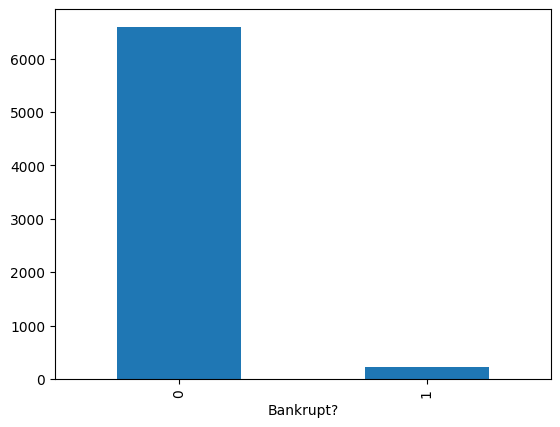

In [3]:
# visually
dataset['Bankrupt?'].value_counts().plot(kind='bar')

It is easy to see that bankrupt is not balanced at all, so some kind of treatment will have to be done. In these types of problems, it is completely normal to have distributions like the one above, as normally business which are listed on the stock exchange tend to operate normally. 

### Missing values, duplicates and constant variables

Now we will be looking for missing values in the dataset

In [4]:
# total number of missing values of the dataset
dataset.isnull().sum().sum() 

np.int64(0)

As the cell output shows, there are not missing values in this dataset.
Now we will be looking for possible duplicated rows in the dataset. 

In [5]:
dataset.duplicated().sum()

np.int64(0)

Again, the number is zero, there are no repeated rows in the data, so we can move on to search constant variables, if there is any.

In [6]:
# the first ten columns with the least number of different values
nunique = dataset.nunique()
nunique.sort_values().head(10)

Net Income Flag                                1
Bankrupt?                                      2
Liability-Assets Flag                          2
Total Asset Turnover                         381
Net Worth Turnover Rate (times)              741
Interest-bearing debt interest rate         1080
Operating Profit Per Share (Yuan ¥)         1236
Persistent EPS in the Last Four Seasons     1358
Per Share Net profit before tax (Yuan ¥)    1522
Research and development expense rate       1536
dtype: int64

As we can see, only 'Net income flag' is constant. The next ones are bankrupt (our target, is a boolean) and 'Liability-Assets Flag', where both of them have two values. It is worth to look deeper on the 'Liability-Assets Flag' variable to see if it should be deleted or not.

In [7]:
dataset['Liability-Assets Flag'].value_counts()

pd.crosstab(dataset['Liability-Assets Flag'], dataset['Bankrupt?'])

Bankrupt?,0,1
Liability-Assets Flag,,
0,6597,214
1,2,6


As the output shows, there are only 8 positive cases (0,12%), so it is a near cero variance. Howevwe, taking into account that the correlation between having more passive than active and bankruptcy is really high, and also given into account that models such XGBoost perform well with these situations, the variable will not be deleted for now.

### Correlation Matrix
In this dataset there are 95 columns, However, a lot of them represent the same concept with slight diffrences (for example, ROA(A), ROA(B), ROA(C)), and mantaning all the columns only adds noise and dimensionality. A heat map is a good tool to visualize all these correlations.



First, we make a general heatmap to have a general pov:

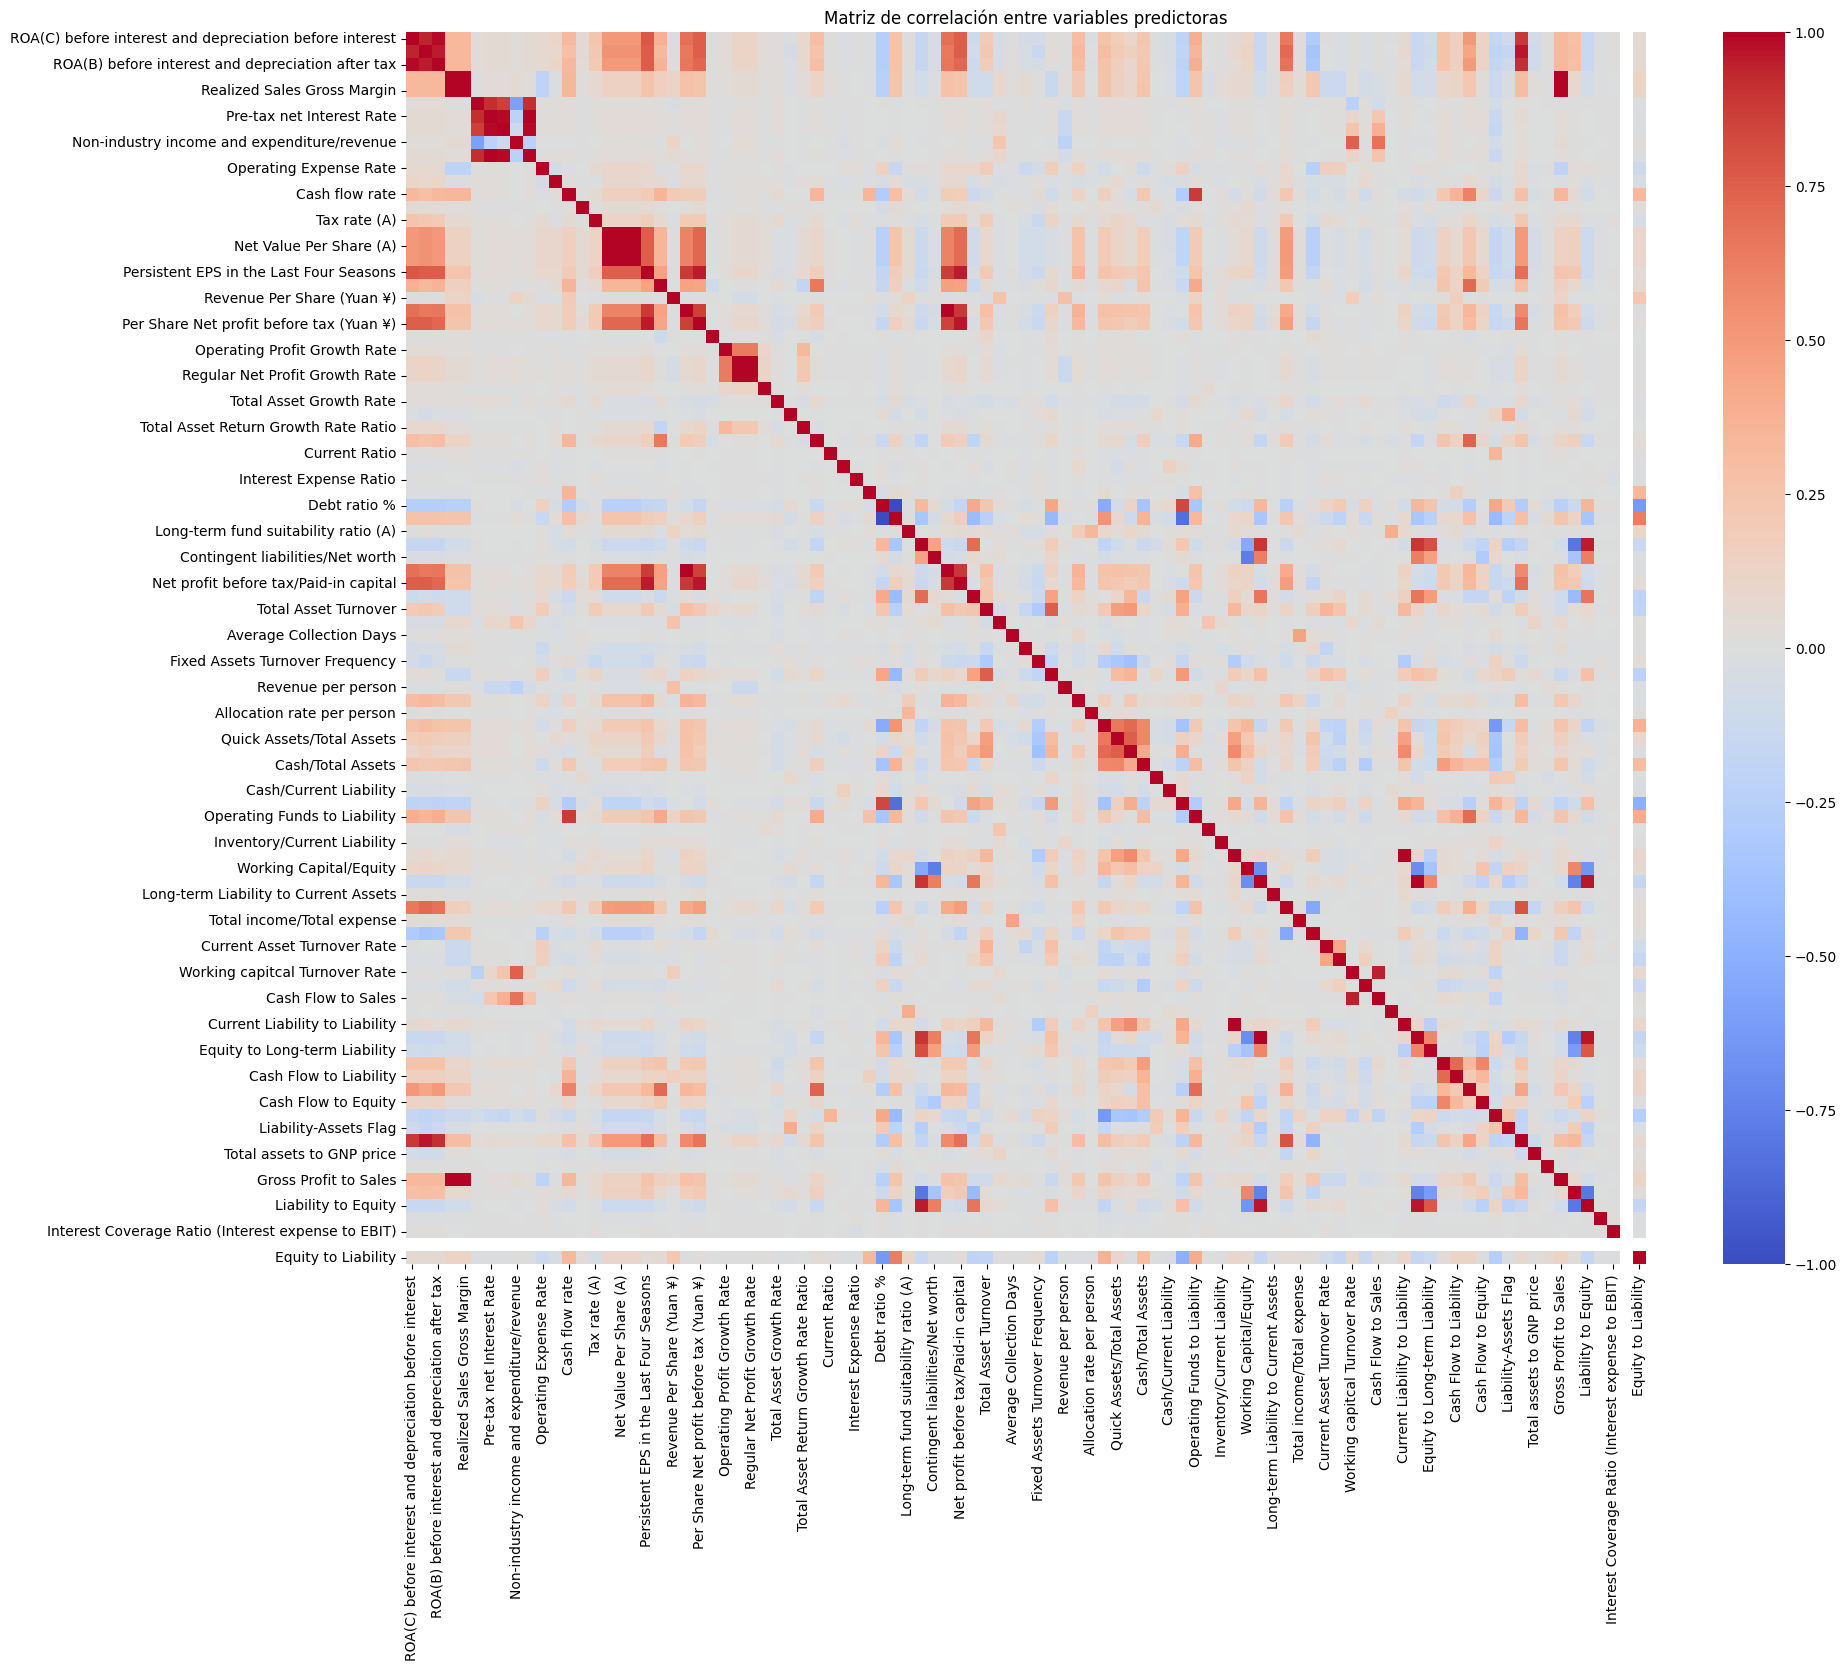

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Matrix
corr_matrix = dataset.drop(columns=['Bankrupt?']).corr()

# Heatmap 
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables predictoras')
plt.show()

As we can see, there are some red 'island' and points. Those red points determine that there is a high correlation between those two variables. Now, we will obtain the pairs which have a correlation higher than 0.9:

In [9]:
# 0.9 is the convention
threshold = 0.9

upper = corr_matrix.where(
    pd.DataFrame(
        [[i < j for j in range(len(corr_matrix.columns))] for i in range(len(corr_matrix.columns))],
        columns=corr_matrix.columns, index=corr_matrix.columns
    )
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'correlation'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'].abs() > threshold].sort_values('correlation', ascending=False)

high_corr_pairs

,var_1,var_2,correlation
6252,Current Liabilities/Equity,Current Liability to Equity,1.000000
6061,Current Liabilities/Liability,Current Liability to Liability,1.000000
373,Operating Gross Margin,Gross Profit to Sales,1.000000
1537,Net Value Per Share (A),Net Value Per Share (C),0.999837
289,Operating Gross Margin,Realized Sales Gross Margin,0.999518
468,Realized Sales Gross Margin,Gross Profit to Sales,0.999518
1441,Net Value Per Share (B),Net Value Per Share (A),0.999342
1442,Net Value Per Share (B),Net Value Per Share (C),0.999179
2036,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998696
2401,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,0.996186


Several pairs showed a perfect correlation of 1.0 (or -1.0), indicating they are mathematically 
identical despite having different names — for example, 'Operating Gross Margin' and 
'Gross Profit to Sales', or 'Debt ratio' and 'Net worth/Assets' (the latter pair is perfectly 
inverse, since both are derived from the accounting identity Assets = Liabilities + Equity). 
A second group of pairs showed correlations between 0.95 and 0.999, corresponding to 
variants of the same underlying metric computed with slightly different accounting treatments 
(e.g., the three versions of 'ROA' and 'Net Value Per Share'). A third, slightly weaker group 
(0.91–0.96) still points to strong redundancy but may retain some distinct signal and warrants 
closer inspection before being dropped.

These results confirm that the dataset's 95 variables are not 95 independent phenomena, but 
rather multiple representations of a small number of underlying financial concepts. 

### Most relevant variables

Now we will look for the most relevant variables in the dataset, in order to get an 
intuition about which parts of the data are most informative for predicting bankruptcy. 
We will do this using boxplots. For each variable, we plot the distribution (Q1, median, 
and Q3) split by the value of Bankrupt. When the boxes for the two classes are clearly 
separated — that is, their interquartile ranges (the boxes themselves) barely or don't 
overlap — that variable is likely a good discriminator between bankrupt and non-bankrupt 
companies. When the boxes overlap heavily, the variable is less informative on its own.

Note that this visual separation is only an intuition, not a rigorous ranking: each subplot 
uses its own Y-axis scale, so the apparent gap between boxes isn't directly comparable across 
different variables.

The cell below plots the boxplots of the 30 variables most correlated with the target.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


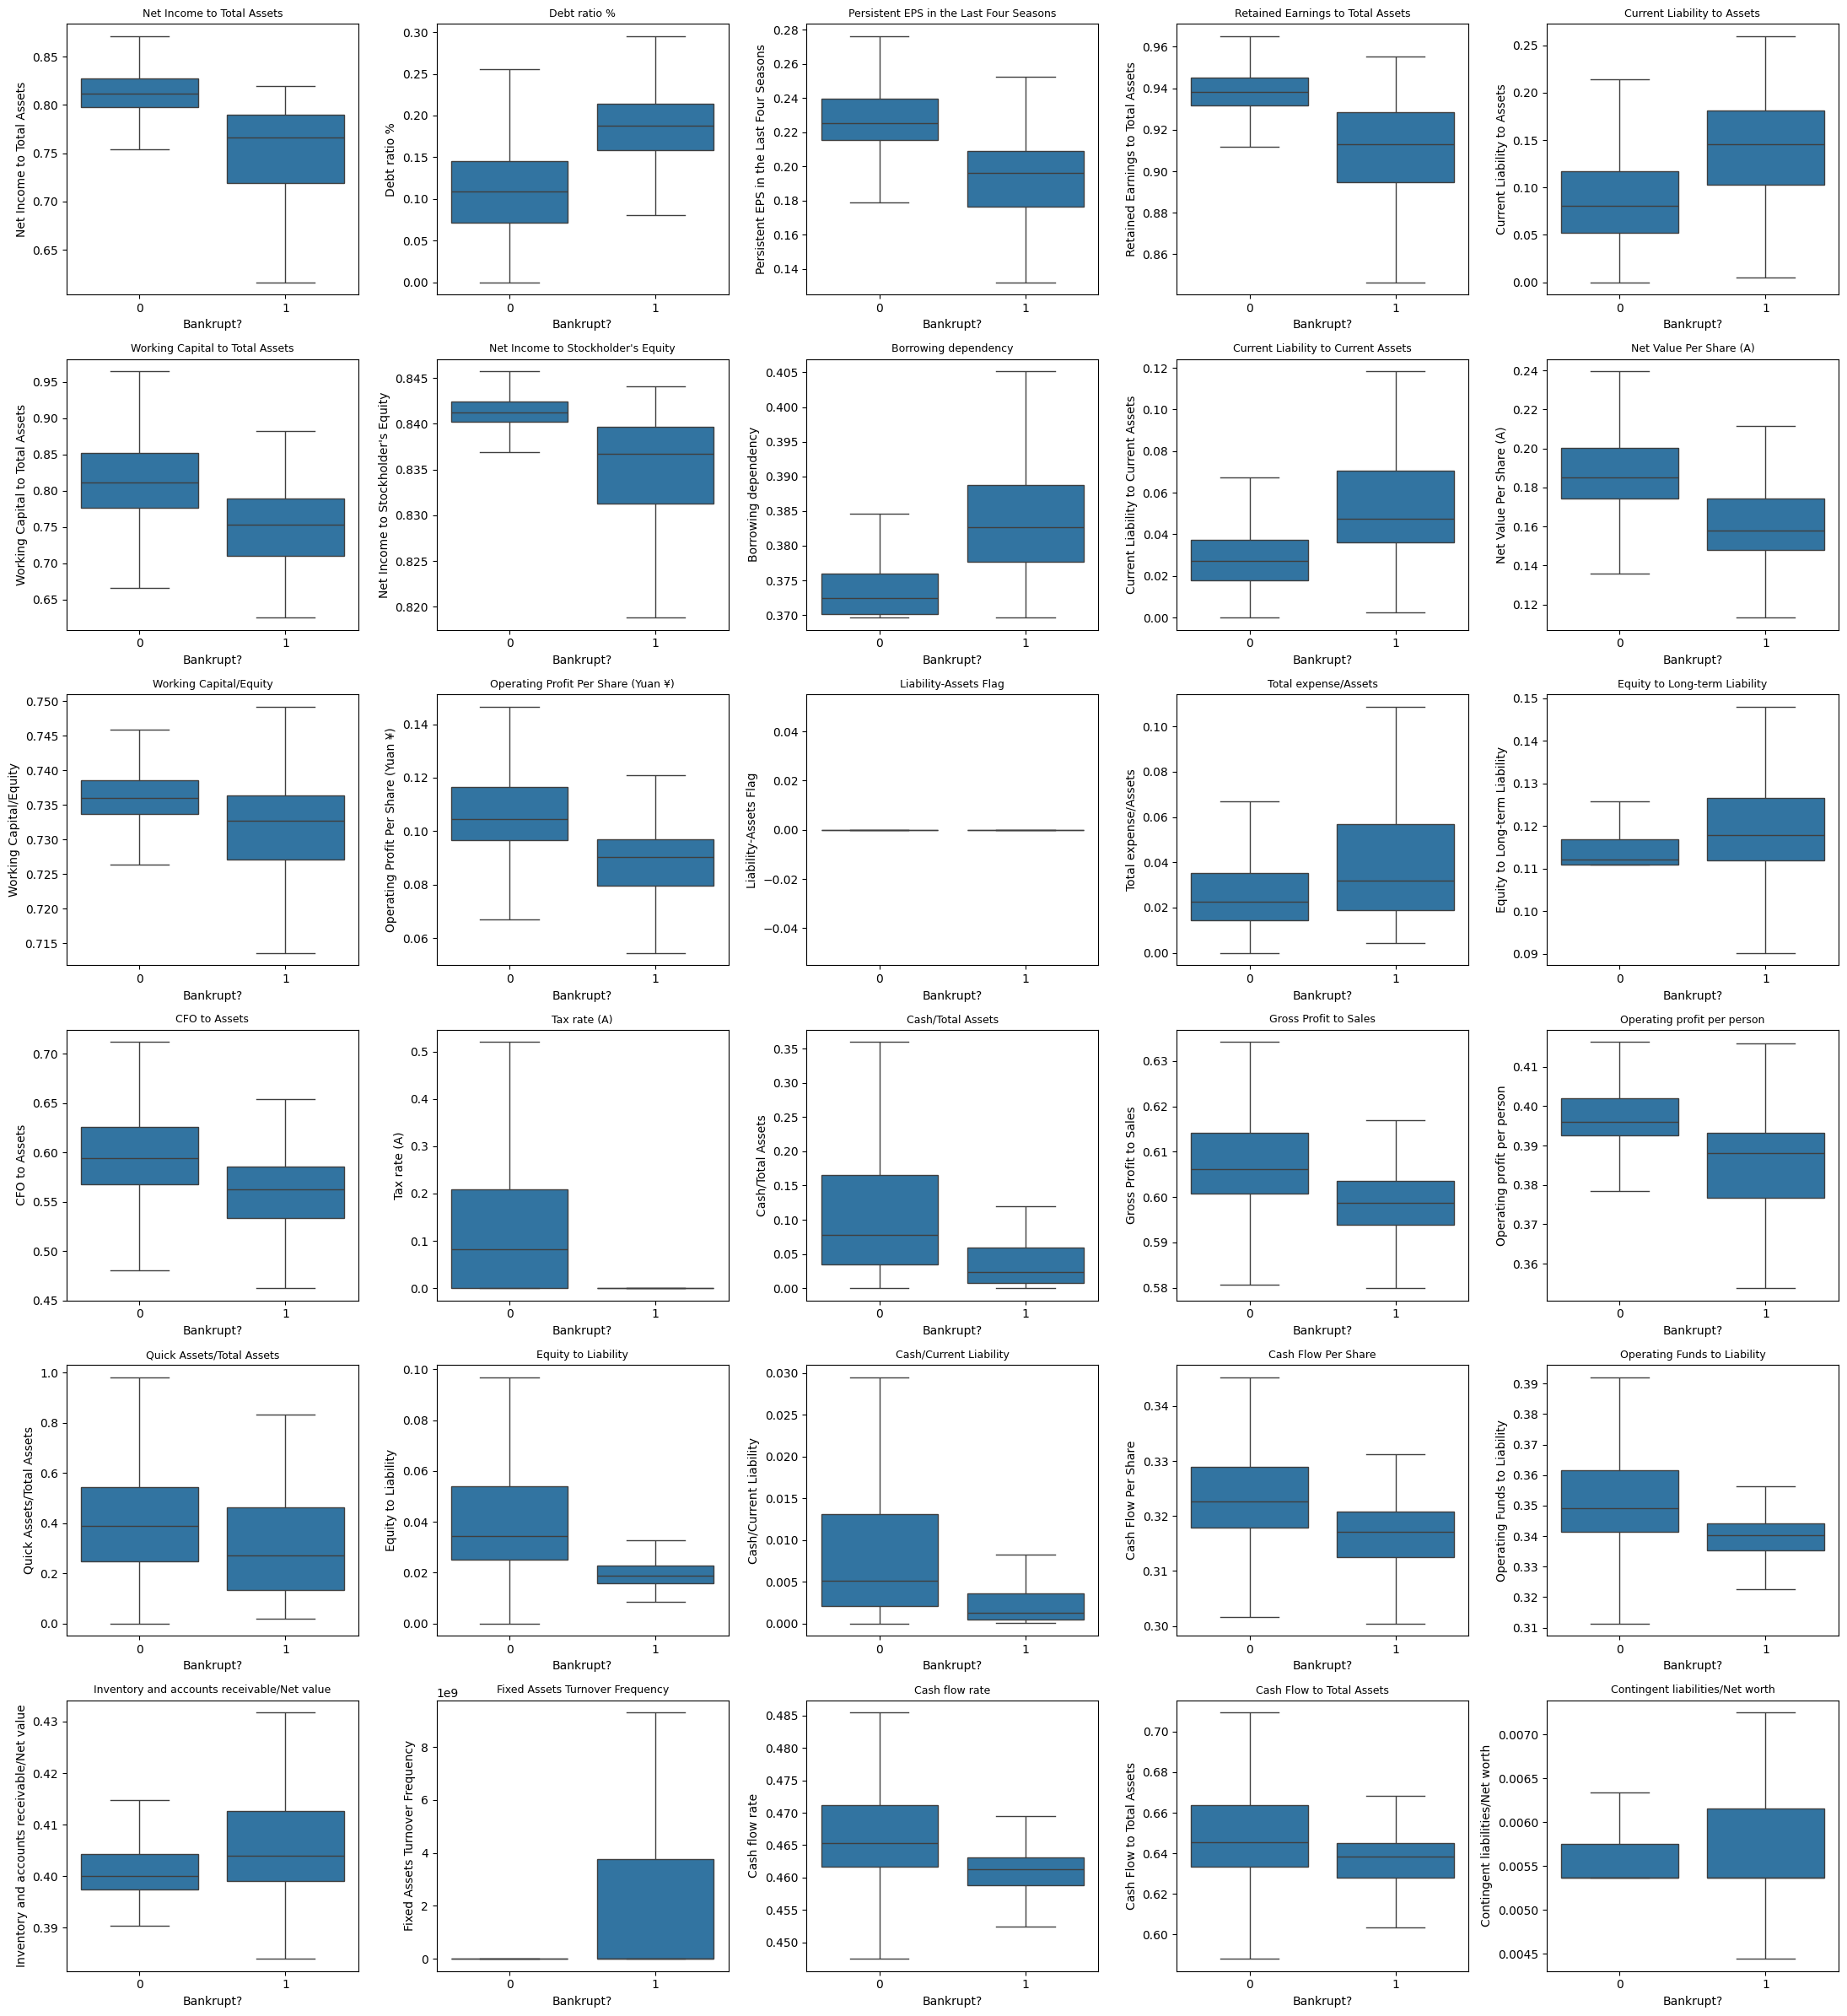

In [10]:
# obtain the correlation of every variable with the target
target_corr = dataset.drop(columns=['Bankrupt?']).corrwith(dataset['Bankrupt?']).abs()

# we choose beetween the variables from above to not repeat correlated variables
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    var1, var2 = row['var_1'], row['var_2']
    loser = var1 if target_corr[var1] < target_corr[var2] else var2
    to_drop.add(loser)

# temporal dataset
dataset_reduced = dataset.drop(columns=list(to_drop))

# reorder the variables in order of correlation target
remaining_ranked = dataset_reduced.drop(columns=['Bankrupt?']).corrwith(dataset_reduced['Bankrupt?']).abs().sort_values(ascending=False)

# 30 most correlated
top_vars = remaining_ranked.head(30).index

# print boxplots
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(6, 5, figsize=(22, 24))
for ax, col in zip(axes.flatten(), top_vars):
    sns.boxplot(data=dataset, x='Bankrupt?', y=col, ax=ax, showfliers=False)
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

With these results, we can extract some meaninful ideas, even though we have not made the model yet:
- If we look to variables such as 'Net income to Total Assets' or 'Persistent EPS', we can observe that a clear separation exist. This is intuitive, because if a business does not have operating revenue nor revenue per share, it is not expected to succeed in the long run.
- We can quite safely say that the business which are more in debt tend to collapse, as the boxplots of variables like 'Debt Ratio' or 'Borrowing Dependency' show (the higher the % of debt, the more probability of bankruptcy).
- Business which does not have a strong 'wealth buffer' usually tend to bankrupt. These can be seen, for example, in the boxplot of 'Equity to liability' or 'Retained earnings to toal assets'.

In general, the classic signals of poor health (and possible bankruptcy) of a business: low income, high debt, low wealth buffer... also appear in this dataset. The future model will take this concepts (the variables behind these concepts) strongly into account, as they tend to separate quite well the two types of business of the dataset.


### Outliers

Last, it is also important to look for outliers, as it will determine which type of scaler will be used in the preprocessing. 

In [11]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = dataset.drop(columns=['Bankrupt?']).apply(count_outliers_iqr)
outlier_pct = (outlier_counts / len(dataset) * 100).sort_values(ascending=False)
outlier_pct.head(44)

Degree of Financial Leverage (DFL)                    22.041355
Interest Coverage Ratio (Interest expense to EBIT)    20.838833
Fixed Assets Turnover Frequency                       20.794838
Current Asset Turnover Rate                           20.516205
Total Asset Growth Rate                               20.252236
Interest Expense Ratio                                19.973603
Cash Flow to Liability                                17.773867
No-credit Interval                                    16.703329
Non-industry income and expenditure/revenue           16.043408
Cash Flow to Sales                                    15.427482
Continuous Net Profit Growth Rate                     15.280833
After-tax Net Profit Growth Rate                      15.148849
Regular Net Profit Growth Rate                        15.104854
Operating Profit Growth Rate                          14.782226
Inventory/Working Capital                             13.843672
Contingent liabilities/Net worth        

Using the standard IQR rule (values beyond 1.5×IQR from Q1/Q3), several columns show an 
unusually high percentage of "outliers" — up to 22% for Degree of Financial Leverage (DFL). 
For a roughly normal distribution, this rule should flag only ~0.7% of values, so percentages 
this high suggest either genuinely heavy-tailed financial ratios, or something structurally 
wrong with these columns rather than natural variability. This motivates a closer look at the 
actual magnitude of the extreme values, not just how many there are.

In [12]:
stats = dataset.drop(columns=['Bankrupt?']).describe().T[['50%', 'max', 'min']]
stats['max_to_median_ratio'] = (stats['max'] / stats['50%'].replace(0, 0.0001)).abs()
stats.sort_values('max_to_median_ratio', ascending=False).head(40)

,50%,max,min,max_to_median_ratio
Current Asset Turnover Rate,1.987816e-04,1.000000e+10,0.0,5.030648e+13
Quick Asset Turnover Rate,2.247728e-04,1.000000e+10,0.0,4.448937e+13
Operating Expense Rate,2.777589e-04,9.990000e+09,0.0,3.596645e+13
Net Value Growth Rate,4.619555e-04,9.330000e+09,0.0,2.019675e+13
Fixed Assets Turnover Frequency,5.930942e-04,9.990000e+09,0.0,1.684387e+13
Inventory Turnover Rate (times),7.646743e-04,9.990000e+09,0.0,1.306439e+13
Accounts Receivable Turnover,9.678107e-04,9.740000e+09,0.0,1.006395e+13
Long-term Liability to Current Assets,1.974619e-03,9.540000e+09,0.0,4.831312e+12
Total assets to GNP price,2.085213e-03,9.820000e+09,0.0,4.709352e+12
Interest-bearing debt interest rate,3.210321e-04,9.900000e+08,0.0,3.083804e+12


Counting outliers is not enough — the IQR rule doesn't tell us how extreme they actually are. 
Comparing each column's maximum to its median reveals a striking pattern: several unrelated 
columns (Current Asset Turnover Rate, Quick Asset Turnover Rate, Fixed Assets Turnover 
Frequency, among others) all have maximums clustering around 9.9e9–1e10, despite having 
medians close to zero. This is not consistent with natural business variability, it strongly 
suggests a sentinel value: a fixed placeholder (e.g. used when a ratio's denominator was 
zero) rather than a real measurement.

In [13]:
# Comprobamos, para cada columna, cuántas filas superan un umbral "imposible" para un ratio financiero normal
threshold = 1e8

sentinel_summary = {}
for col in dataset.drop(columns=['Bankrupt?']).columns:
    n_sentinel = (dataset[col] > threshold).sum()
    if n_sentinel > 0:
        sentinel_summary[col] = n_sentinel

sentinel_summary = pd.Series(sentinel_summary).sort_values(ascending=False)
sentinel_summary

Total Asset Growth Rate                  5959
Cash Turnover Rate                       4151
Research and development expense rate    3907
Inventory Turnover Rate (times)          2669
Quick Asset Turnover Rate                2362
Operating Expense Rate                   2252
Fixed Assets Turnover Frequency          1223
Current Asset Turnover Rate              1215
Interest-bearing debt interest rate       175
Long-term Liability to Current Assets     101
Inventory/Current Liability                96
Cash/Current Liability                     46
Accounts Receivable Turnover               22
Total assets to GNP price                  20
Average Collection Days                    18
Allocation rate per person                 11
Quick Ratio                                 9
Total debt/Total net worth                  8
Revenue Per Share (Yuan ¥)                  5
Quick Assets/Current Liability              3
Revenue per person                          2
Net Value Growth Rate             

Checking how many rows exceed a threshold of 1e8 confirms the sentinel hypothesis, and reveals 
two distinct groups. A small set of columns (Total Asset Growth Rate: 87.4%, Cash Turnover 
Rate: 60.9%, R&D expense rate: 57.3%, and a few more down to Current Asset Turnover Rate: 
17.8%) have the sentinel value in a very large share of rows, in these cases, most of the 
column's content is not a real measurement at all. The remaining affected columns have the 
sentinel value in 10% or fewer of their rows, making them reasonable candidates for imputation 
rather than removal.

In [14]:
# ¿Las filas afectadas se solapan entre columnas, o son distintas cada vez?
sentinel_masks = {col: dataset[col] > threshold for col in sentinel_summary.index}
overlap_matrix = pd.DataFrame(sentinel_masks).sum(axis=1).value_counts().sort_index()
overlap_matrix


0      74
1     530
2    1102
3    1656
4    1568
5    1158
6     630
7      94
8       7
Name: count, dtype: int64

Only 74 rows (1.1% of the dataset) have no sentinel value in any of these columns — meaning 
98.9% of companies are affected in at least one column, and most are affected in 3 to 5 columns 
simultaneously. This rules out simply dropping the affected rows, since that would discard 
almost the entire dataset. The pattern points to a systematic artifact in how these specific 
ratios were originally computed (most likely division by a value that is frequently zero), 
rather than isolated data-entry errors.